# Instacart Market Basket Analysis

**MBA Business Strategy Pipeline** — 7-step analytics pipeline that turns 3M+ Instacart grocery orders into actionable business insights.

| Step | Analysis | Algorithm | Business Value |
|------|----------|-----------|----------------|
| 1 | User Loyalty | Reorder rate segmentation | VIP vs At-Risk customers |
| 2 | Product Velocity | Purchase frequency tiers | Inventory & shelf placement |
| 3 | Add-to-Cart Priority | Cart position analysis | Destination vs impulse products |
| 4 | Aisle Affinity | Normalised co-occurrence | Digital shelf placement & navigation |
| 5 | Cross-Sell Bundles | Item-Item CF (Jaccard similarity) | "Also bought" recommendations |
| 6 | Trip Missions | K-Means clustering | Mission-based marketing |
| 7 | Reorder Propensity | Logistic Regression (Prior→Train split) | Timing-aware recommendations |

**Academic References:**
- Linden et al. (2003). "Amazon.com Recommendations: Item-to-Item CF." *IEEE Internet Computing*
- Jaccard, P. (1912). "The Distribution of the Flora in the Alpine Zone." *New Phytologist* — used in Cross-Sell (Step 5)

## Setup & Configuration

In [138]:
# ─── SETUP & CONFIGURATION ───────────────────────────────────────────
# Load all the software libraries (tools) needed for this analysis
# Think of these as opening different "toolboxes" before starting work

import sys
from pathlib import Path
from collections import Counter

# NumPy: for mathematical operations on large datasets
import numpy as np
# Pandas: for working with spreadsheet-like data tables
import pandas as pd
# Polars: a faster alternative to Pandas for loading large CSV files
import polars as pl
# Matplotlib: for creating charts and visualizations
import matplotlib.pyplot as plt
# combinations: for generating all possible pairs of items
from itertools import combinations
from collections import Counter as Ctr
# SciPy & Scikit-learn: industry-standard tools for machine learning
from scipy.sparse import csr_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# Display charts directly inside the notebook
%matplotlib inline
# Make charts higher resolution and with white backgrounds for readability
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Add local helper code to the search path
sys.path.insert(0, str(Path('.') / 'src'))

# Define a consistent color scheme for all visualizations across the analysis
# Each business tier gets its own recognizable color for easy visual comparison
PALETTE = {
    'VIP': '#2ecc71', 'Loyal': '#3498db', 'Regular': '#f39c12', 'At-Risk': '#e74c3c',
    'High': '#2ecc71', 'Medium': '#3498db', 'Low': '#f39c12', 'Very Low': '#e74c3c',
    'Destination': '#2ecc71', 'Planned': '#3498db', 'Considered': '#f39c12', 'Impulse': '#e74c3c',
}

# We analyze 15% of all customers to keep processing time reasonable
# while still maintaining statistical significance (~31,000 users)
SAMPLE_SIZE = 0.15
# The specific product we'll use as a case study throughout the analysis
PRODUCT_NAME = 'Cucumber Kirby'

print('Setup complete.')


Setup complete.


## Data Loading

Load the Instacart dataset using Polars (3-5x faster than Pandas for CSV loading). We sample 15% of users to keep runtime manageable while preserving statistical significance.

In [139]:
# ─── DATA LOADING ─────────────────────────────────────────────────────
# Load all the raw data files that make up Instacart's transaction history
# This is like pulling sales reports from different parts of the business

# Set the folder where our data files live
dataset_path = Path('data/instacart')
# If data isn't available locally, download it automatically from Kaggle
if not dataset_path.exists() or not list(dataset_path.iterdir()):
    import kagglehub
    dataset_path = Path(kagglehub.dataset_download('psparks/instacart-market-basket-analysis'))
    print(f'Downloaded to: {dataset_path}')

# Load the product catalog — every product Instacart sells (name, aisle, department)
products = pl.read_csv(dataset_path / 'products.csv')
# Load the store layout — the 134 aisles products are organized into
aisles = pl.read_csv(dataset_path / 'aisles.csv')
# Load the department list — the 21 broad departments (produce, dairy, etc.)
departments = pl.read_csv(dataset_path / 'departments.csv')
# Load all customer orders — who ordered, when, and in what sequence
orders = pl.read_csv(dataset_path / 'orders.csv')
# Load the items in each historical order — what each customer bought in the past
order_products = pl.read_csv(dataset_path / 'order_products__prior.csv')
# Load the items in each customer's most recent order — used later as our prediction target
order_products_train = pl.read_csv(dataset_path / 'order_products__train.csv')

# ─── SAMPLING ─────────────────────────────────────────────────────────
# Take a random 15% sample of customers to keep the analysis manageable
# This is standard practice — like polling 1,000 voters to predict an election
unique_users = orders.select('user_id').unique()
n_users = int(len(unique_users) * SAMPLE_SIZE)
# seed=42 ensures we get the same random sample every time we run the analysis
sampled_users = unique_users.sample(n_users, seed=42)
# Keep only orders from our sampled customers
orders = orders.join(sampled_users, on='user_id', how='inner')
# Keep only order items that belong to our sampled customers' orders
order_products = order_products.join(orders.select('order_id'), on='order_id', how='inner')
order_products_train = order_products_train.join(orders.select('order_id'), on='order_id', how='inner')

# Convert all data to Pandas format for the rest of the analysis
# (Polars is faster for loading, but Pandas has broader analysis features)
products_pd = products.to_pandas()
aisles_pd = aisles.to_pandas()
departments_pd = departments.to_pandas()
orders_pd = orders.to_pandas()
op_pd = order_products.to_pandas()
op_train_pd = order_products_train.to_pandas()

# Look up our case study product (Cucumber Kirby) in the product catalog
# We'll track this product through every step of the analysis as a concrete example
product_row = products_pd[products_pd['product_name'].str.lower() == PRODUCT_NAME.lower()]
PRODUCT_ID = int(product_row.iloc[0]['product_id'])
PRODUCT_AISLE_ID = int(product_row.iloc[0]['aisle_id'])

# Print a summary of how much data we're working with
print(f'Orders:         {len(orders_pd):>10,}')
print(f'Order-products (prior): {len(op_pd):>10,}')
print(f'Order-products (train): {len(op_train_pd):>10,}')
print(f'Products:               {len(products_pd):>10,}')
print(f'Aisles:         {len(aisles_pd):>10,}')
print(f'Users sampled:  {n_users:>10,} ({SAMPLE_SIZE:.0%})')
print(f'\nTarget product: {PRODUCT_NAME} (id={PRODUCT_ID}, aisle_id={PRODUCT_AISLE_ID})')


Orders:            517,301
Order-products (prior):  4,900,510
Order-products (train):    208,372
Products:                   49,688
Aisles:                134
Users sampled:      30,931 (15%)

Target product: Cucumber Kirby (id=49683, aisle_id=83)


---
## Step 1: User Loyalty

**Business Question:** How loyal is each customer?

We compute each user's reorder rate (fraction of items that are reorders) and segment them into loyalty tiers:
- **VIP** (≥70%): High-value customers worth retaining
- **Loyal** (≥50%): Consistent repeat buyers
- **Regular** (≥30%): Moderate engagement
- **At-Risk** (<30%): May need re-engagement campaigns

In [140]:
# ─── STEP 1: USER LOYALTY ─────────────────────────────────────────────
# Goal: Classify every customer into a loyalty tier based on how often
# they repurchase products they've bought before.
# Business Value: Identifies VIP customers worth retaining and At-Risk
# customers who need re-engagement campaigns.

# Combine order data with product-level reorder flags
# This tells us, for each item in every order, whether the customer had bought it before
user_orders = orders_pd.merge(op_pd[['order_id', 'reordered']], on='order_id', how='inner')

# For each customer, calculate:
#   - total_orders: how many items they've ordered overall (basket depth)
#   - reorder_rate: what percentage of their items are repeat purchases (loyalty signal)
loyalty = (
    user_orders
    .groupby('user_id')
    .agg(total_orders=('order_id', 'count'), reorder_rate=('reordered', 'mean'))
    .reset_index()
)

# Classify each customer into a loyalty tier based on their reorder rate
# VIP (≥70% reorders): these customers are creatures of habit — high-value, worth retaining
# Loyal (≥50%): consistent repeat buyers — reliable revenue
# Regular (≥30%): moderate engagement — potential to upgrade with targeted offers
# At-Risk (<30%): mostly buying new things each time — may be exploring or about to leave
loyalty['loyalty_tier'] = loyalty['reorder_rate'].apply(
    lambda x: 'VIP' if x >= 0.7 else 'Loyal' if x >= 0.5 else 'Regular' if x >= 0.3 else 'At-Risk'
)

# Display the results — how many customers fall in each loyalty tier
print(f'Total users: {len(loyalty):,}')
print(f'\nLoyalty Tier Distribution:')
print(loyalty['loyalty_tier'].value_counts().reindex(['VIP', 'Loyal', 'Regular', 'At-Risk']))
print(f'\nMedian reorder rate: {loyalty["reorder_rate"].median():.3f}')

# Show the first 10 customers with their loyalty data
loyalty.head(10)


Total users: 30,931

Loyalty Tier Distribution:
loyalty_tier
VIP        3807
Loyal      8749
Regular    9265
At-Risk    9110
Name: count, dtype: int64

Median reorder rate: 0.434


,user_id,total_orders,reorder_rate,loyalty_tier
0,13,81,0.641975,Loyal
1,14,210,0.323810,Regular
2,16,70,0.342857,Regular
3,22,69,0.507246,Loyal
4,24,38,0.526316,Loyal
5,30,11,0.454545,Regular
6,36,153,0.640523,Loyal
7,44,37,0.189189,At-Risk
8,54,619,0.596123,Loyal
9,79,93,0.473118,Regular


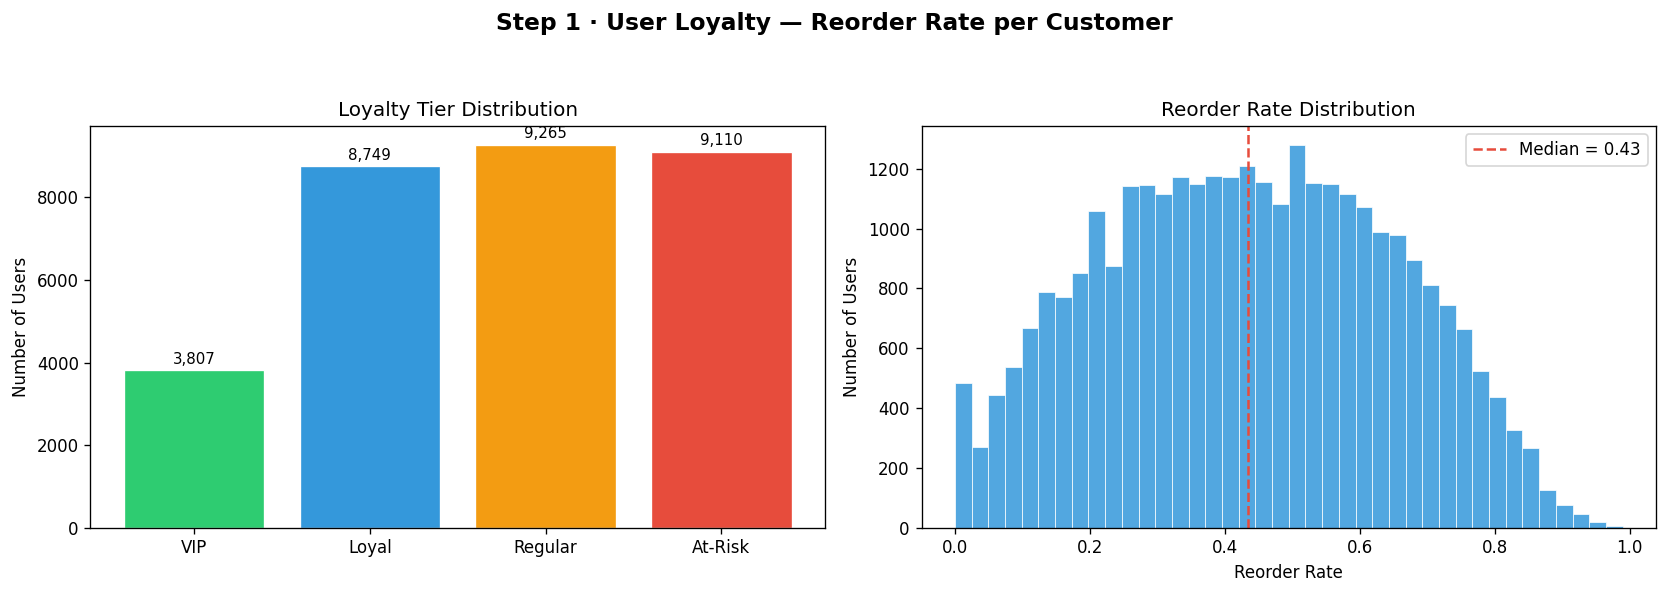

In [141]:
# ─── STEP 1 VISUALIZATION ─────────────────────────────────────────────
# Create two side-by-side charts to visualize customer loyalty patterns

# Set up two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 1 · User Loyalty — Reorder Rate per Customer', fontsize=14, fontweight='bold')

# LEFT CHART: Bar chart showing how many customers fall in each loyalty tier
# This helps marketing decide how to allocate retention vs. acquisition budget
tier_order = ['VIP', 'Loyal', 'Regular', 'At-Risk']
counts = loyalty['loyalty_tier'].value_counts().reindex(tier_order).fillna(0)
colors = [PALETTE[t] for t in tier_order]
bars = axes[0].bar(tier_order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Loyalty Tier Distribution')
# Add the exact count above each bar for precision
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9)

# RIGHT CHART: Histogram of reorder rates across all customers
# Shows the full distribution — are most customers clustered around a certain loyalty level?
axes[1].hist(loyalty['reorder_rate'], bins=40, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Reorder Rate')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Reorder Rate Distribution')
# Red dashed line marks the median — half of customers are above, half below
axes[1].axvline(loyalty['reorder_rate'].median(), color='#e74c3c', ls='--', lw=1.5,
                label=f'Median = {loyalty["reorder_rate"].median():.2f}')
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Step 2: Product Velocity

**Business Question:** Which products sell the most?

Purchase frequency per product, tiered into High / Medium / Low / Very Low. High-velocity products drive inventory decisions.

In [142]:
# ─── STEP 2: PRODUCT VELOCITY ─────────────────────────────────────────
# Goal: Rank every product by how frequently it's purchased
# Business Value: High-velocity products drive inventory planning, shelf
# placement decisions, and supply chain priority.

# Count how many times each product has been purchased across all orders
velocity = op_pd.groupby('product_id').size().reset_index(name='purchase_count')
# Sort from most-purchased to least-purchased
velocity = velocity.sort_values('purchase_count', ascending=False)

# Calculate the 25th, 50th, and 75th percentile thresholds
# These quartiles divide products into four equally-sized tiers
p75 = velocity['purchase_count'].quantile(0.75)
p50 = velocity['purchase_count'].quantile(0.50)
p25 = velocity['purchase_count'].quantile(0.25)

# Classify each product into a velocity tier
# High: top 25% best-sellers — always keep in stock, prioritize in supply chain
# Medium: above-average sellers — solid performers
# Low: below-average but still selling — monitor for trends
# Very Low: bottom 25% — consider whether shelf space is justified
velocity['velocity_tier'] = velocity['purchase_count'].apply(
    lambda x: 'High' if x >= p75 else 'Medium' if x >= p50 else 'Low' if x >= p25 else 'Very Low'
)

# Check where our case study product (Cucumber Kirby) falls
v_row = velocity[velocity['product_id'] == PRODUCT_ID]
purchase_count = int(v_row.iloc[0]['purchase_count']) if not v_row.empty else None
velocity_tier = str(v_row.iloc[0]['velocity_tier']) if not v_row.empty else None

print(f'{PRODUCT_NAME}: {purchase_count:,} purchases ({velocity_tier} velocity)')
print(f'\nVelocity Tier Distribution:')
print(velocity['velocity_tier'].value_counts().reindex(['High', 'Medium', 'Low', 'Very Low']))

# Show top 100 best-selling products with their names
velocity.head(100).merge(products_pd[['product_id', 'product_name']], on='product_id')


Cucumber Kirby: 15,097 purchases (High velocity)

Velocity Tier Distribution:
velocity_tier
High        11151
Medium      11139
Low         13284
Very Low     8797
Name: count, dtype: int64


,product_id,purchase_count,velocity_tier,product_name
0,24852,71292,High,Banana
1,13176,57193,High,Bag of Organic Bananas
2,21137,39597,High,Organic Strawberries
3,21903,36446,High,Organic Baby Spinach
4,47209,31713,High,Organic Hass Avocado
...,...,...,...,...
95,20995,5184,High,Organic Broccoli Florets
96,37687,5155,High,Organic Spring Mix
97,40604,5148,High,Feta Cheese Crumbles
98,38689,5140,High,Organic Reduced Fat Milk


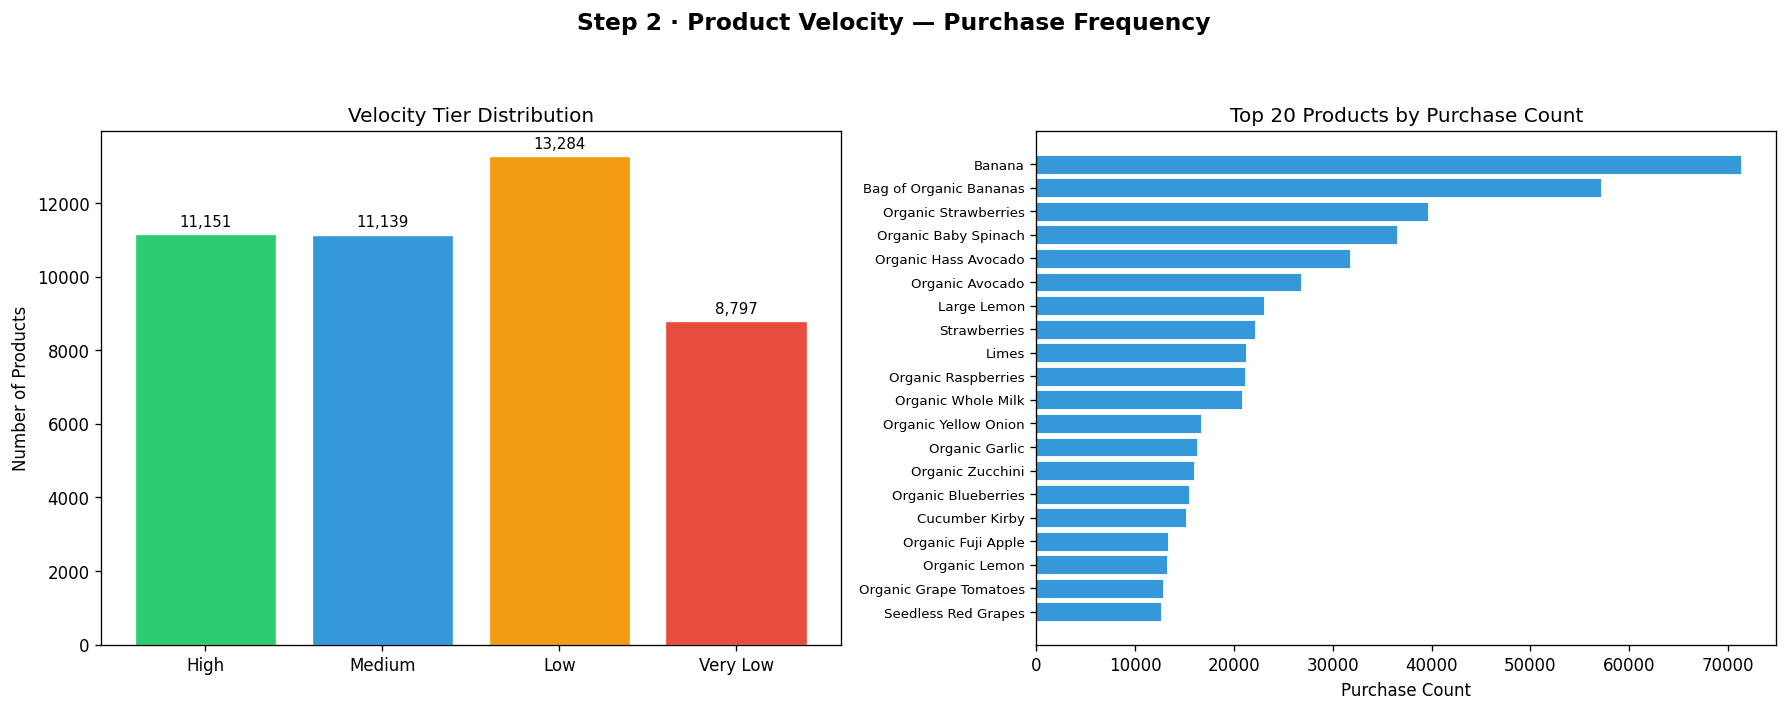

In [143]:
# ─── STEP 2 VISUALIZATION ─────────────────────────────────────────────
# Two charts: (1) How products are distributed across velocity tiers,
# (2) The top 20 best-selling products by name

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Step 2 · Product Velocity — Purchase Frequency', fontsize=14, fontweight='bold')

# LEFT CHART: Bar chart of product counts per velocity tier
# Helps the category manager understand the shape of the product portfolio
tier_order = ['High', 'Medium', 'Low', 'Very Low']
counts = velocity['velocity_tier'].value_counts().reindex(tier_order).fillna(0)
colors = [PALETTE[t] for t in tier_order]
bars = axes[0].bar(tier_order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylabel('Number of Products')
axes[0].set_title('Velocity Tier Distribution')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9)

# RIGHT CHART: Horizontal bar chart of the top 20 products by total purchases
# These are the "hero products" that drive the most volume — Banana is #1 by a wide margin
top20 = velocity.head(20).merge(products_pd[['product_id', 'product_name']], on='product_id', how='left')
top20 = top20.sort_values('purchase_count')
axes[1].barh(range(len(top20)), top20['purchase_count'].values, color='#3498db', edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20['product_name'].fillna(top20['product_id'].astype(str)).values, fontsize=8)
axes[1].set_xlabel('Purchase Count')
axes[1].set_title('Top 20 Products by Purchase Count')

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Step 3: Add-to-Cart Priority

**Business Question:** Is this a destination or impulse product?

Average cart position per product reveals shopping intent:
- **Destination** (≤3): First items added — customers came specifically for these
- **Planned** (≤7): Expected purchases
- **Considered** (≤15): Added after browsing
- **Impulse** (>15): Last-minute additions

In [144]:
# ─── STEP 3: ADD-TO-CART PRIORITY ─────────────────────────────────────
# Goal: Determine whether each product is a "destination" item (the reason
# the customer opened the app) or an "impulse" item (added on a whim).
# Business Value: Destination products should be prominently placed and
# always in stock; impulse items benefit from strategic placement and promotions.

# For each product, calculate its average position in customers' carts
# Products added first (position 1, 2, 3) are what the customer came to buy
# Products added later are more likely impulse or "oh, I also need that" items
cart_priority = (
    op_pd.groupby('product_id')
    .agg(avg_cart_position=('add_to_cart_order', 'mean'))
    .reset_index()
)

# Classify products based on when they're typically added to the cart
# Destination (≤3): The first items customers grab — these drive store visits
# Planned (≤7): Pre-decided purchases — on the shopping list
# Considered (≤15): Browsing purchases — customer is comparing options
# Impulse (>15): Late additions — added after the customer has already filled their cart
cart_priority['priority_type'] = cart_priority['avg_cart_position'].apply(
    lambda x: 'Destination' if x <= 3 else 'Planned' if x <= 7 else 'Considered' if x <= 15 else 'Impulse'
)
cart_priority = cart_priority.sort_values('avg_cart_position')

# Check our case study product: is Cucumber Kirby a destination or impulse buy?
c_row = cart_priority[cart_priority['product_id'] == PRODUCT_ID]
avg_cart_position = float(c_row.iloc[0]['avg_cart_position']) if not c_row.empty else None
priority_type = str(c_row.iloc[0]['priority_type']) if not c_row.empty else None

print(f'{PRODUCT_NAME}: avg cart position {avg_cart_position:.2f} ({priority_type})')
print(f'\nPriority Type Distribution:')
print(cart_priority['priority_type'].value_counts().reindex(['Destination', 'Planned', 'Considered', 'Impulse']))


Cucumber Kirby: avg cart position 7.56 (Considered)

Priority Type Distribution:
priority_type
Destination     2188
Planned        10376
Considered     28734
Impulse         3073
Name: count, dtype: int64


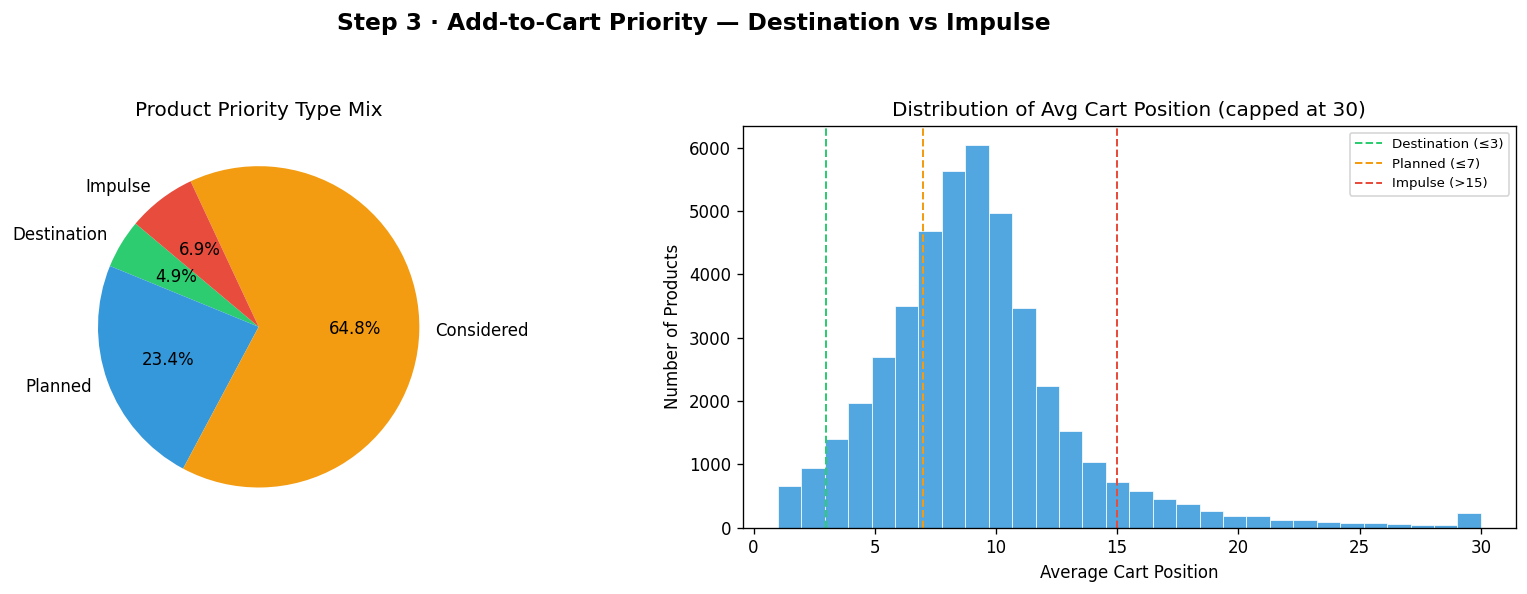

In [145]:
# ─── STEP 3 VISUALIZATION ─────────────────────────────────────────────
# Two charts: (1) Pie chart of product priority mix,
# (2) Histogram showing the distribution of average cart positions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 3 · Add-to-Cart Priority — Destination vs Impulse', fontsize=14, fontweight='bold')

# LEFT CHART: Pie chart showing the split between Destination, Planned, Considered, and Impulse
# This reveals the overall shopping behavior pattern on the platform
type_order = ['Destination', 'Planned', 'Considered', 'Impulse']
counts = cart_priority['priority_type'].value_counts().reindex(type_order).fillna(0)
colors = [PALETTE[t] for t in type_order]
axes[0].pie(counts.values, labels=type_order, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Product Priority Type Mix')

# RIGHT CHART: Histogram of average cart positions
# The dashed lines show the cutoff boundaries between tiers
# Most products are added in the middle positions (Planned/Considered zone)
axes[1].hist(cart_priority['avg_cart_position'].clip(upper=30), bins=30,
             color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Average Cart Position')
axes[1].set_ylabel('Number of Products')
axes[1].set_title('Distribution of Avg Cart Position (capped at 30)')
axes[1].axvline(3, color='#2ecc71', ls='--', lw=1.2, label='Destination (≤3)')
axes[1].axvline(7, color='#f39c12', ls='--', lw=1.2, label='Planned (≤7)')
axes[1].axvline(15, color='#e74c3c', ls='--', lw=1.2, label='Impulse (>15)')
axes[1].legend(fontsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Step 4: Aisle Affinity (Normalised Co-Occurrence)

**Business Question:** Which aisles are co-browsed / co-purchased?

**Algorithm:** Normalised Co-Occurrence

$$\text{affinity}(A, B) = \frac{\text{baskets containing both A and B}}{\min(\text{baskets containing A},\;\text{baskets containing B})}$$

Dividing by the **minimum** individual count prevents popular aisles from dominating — a small aisle that always co-occurs with a large one scores 1.0. Produces a symmetric aisle affinity matrix.

In [146]:
# ─── STEP 4: AISLE AFFINITY (CO-OCCURRENCE) ──────────────────────────
# Goal: Discover which store aisles are most frequently visited together
# in the same shopping trip (order).
# Business Value: Informs store layout, digital navigation, and
# "You might also need…" recommendations at the aisle level.

# Create a lookup table: aisle ID → aisle name (e.g., 83 → "fresh vegetables")
aisle_names = dict(zip(aisles_pd['aisle_id'], aisles_pd['aisle']))
print(aisle_names)

# For each order, figure out which aisles the customer visited
# First, connect each product in each order to its aisle
op_with_aisle = op_pd[['order_id', 'product_id']].merge(
    products_pd[['product_id', 'aisle_id']], on='product_id', how='inner'
)
# Then, for each order, collect the unique set of aisles the customer shopped from
basket_aisles = op_with_aisle.groupby('order_id')['aisle_id'].apply(set)
print(basket_aisles)

# Count how often each pair of aisles appears together in the same basket
# Also count how many baskets each individual aisle appears in (for normalization)
pair_both = Ctr()
solo_counts = Ctr()
for aisle_set in basket_aisles:
    for aid in aisle_set:
        solo_counts[aid] += 1
    # Generate all possible pairs from the aisles in this basket
    for a, b in combinations(sorted(aisle_set), 2):
        pair_both[(a, b)] += 1

all_aisles = sorted(solo_counts.keys())
print(all_aisles)
n_aisles = len(all_aisles)
aisle_to_idx = {aid: i for i, aid in enumerate(all_aisles)}

# Build the affinity matrix: for each pair of aisles, calculate a normalized
# co-occurrence score. We divide by the smaller aisle's solo count to get
# a score between 0 and 1 — this prevents popular aisles from dominating.
# A score of 0.8 means "80% of the time someone visits aisle A, they also visit aisle B"
affinity_matrix = np.zeros((n_aisles, n_aisles))
for (a, b), count in pair_both.items():
    i, j = aisle_to_idx[a], aisle_to_idx[b]
    norm = min(solo_counts[a], solo_counts[b])
    affinity = count / norm if norm > 0 else 0.0
    affinity_matrix[i][j] = affinity
    affinity_matrix[j][i] = affinity

# Store the result as a readable table (aisles × aisles)
affinity_df = pd.DataFrame(affinity_matrix, index=all_aisles, columns=all_aisles)

print(affinity_df)

print(f'Aisle affinity (co-occurrence): {n_aisles} aisles, {len(pair_both):,} pairs across {len(basket_aisles):,} baskets')


{1: 'prepared soups salads', 2: 'specialty cheeses', 3: 'energy granola bars', 4: 'instant foods', 5: 'marinades meat preparation', 6: 'other', 7: 'packaged meat', 8: 'bakery desserts', 9: 'pasta sauce', 10: 'kitchen supplies', 11: 'cold flu allergy', 12: 'fresh pasta', 13: 'prepared meals', 14: 'tofu meat alternatives', 15: 'packaged seafood', 16: 'fresh herbs', 17: 'baking ingredients', 18: 'bulk dried fruits vegetables', 19: 'oils vinegars', 20: 'oral hygiene', 21: 'packaged cheese', 22: 'hair care', 23: 'popcorn jerky', 24: 'fresh fruits', 25: 'soap', 26: 'coffee', 27: 'beers coolers', 28: 'red wines', 29: 'honeys syrups nectars', 30: 'latino foods', 31: 'refrigerated', 32: 'packaged produce', 33: 'kosher foods', 34: 'frozen meat seafood', 35: 'poultry counter', 36: 'butter', 37: 'ice cream ice', 38: 'frozen meals', 39: 'seafood counter', 40: 'dog food care', 41: 'cat food care', 42: 'frozen vegan vegetarian', 43: 'buns rolls', 44: 'eye ear care', 45: 'candy chocolate', 46: 'mint g

In [147]:
# ─── STEP 4: TOP AISLE PAIRS & PRODUCT-SPECIFIC PARTNERS ─────────────
# Goal: Identify the strongest aisle-level shopping associations and
# show which aisles are most related to our case study product's aisle.

# Extract all non-zero aisle pairs and sort by affinity strength
# These are the aisles customers visit together most predictably
pairs = []
for i in range(n_aisles):
    for j in range(i + 1, n_aisles):
        score = affinity_matrix[i, j]
        if score > 0:
            pairs.append({
                'aisle_a': aisle_names.get(all_aisles[i], str(all_aisles[i])),
                'aisle_b': aisle_names.get(all_aisles[j], str(all_aisles[j])),
                'affinity_score': score,
            })
# Show the top 15 aisle pairs — these should be placed near each other in the store
top_pairs = pd.DataFrame(pairs).sort_values('affinity_score', ascending=False).head(15).reset_index(drop=True)

# For our case study product (Cucumber Kirby, in "fresh vegetables" aisle),
# find which aisles are most frequently visited in the same shopping trip
product_aisle_label = aisle_names.get(PRODUCT_AISLE_ID, f'aisle_{PRODUCT_AISLE_ID}')
aisle_row = affinity_df.loc[PRODUCT_AISLE_ID].drop(PRODUCT_AISLE_ID)
aisle_partners = aisle_row.sort_values(ascending=False).head(5)

print(f'\nTop 15 Aisle Pairs by Normalised Co-Occurrence:')
display(top_pairs)

# These partner aisles are candidates for cross-aisle promotions and navigation shortcuts
print(f'\nTop partners for "{product_aisle_label}":')
for aid, score in aisle_partners.items():
    print(f'  {aisle_names.get(aid, aid):30s} affinity={score:.3f}')



Top 15 Aisle Pairs by Normalised Co-Occurrence:


,aisle_a,aisle_b,affinity_score
0,fresh herbs,fresh vegetables,0.842206
1,fresh fruits,seafood counter,0.773820
2,seafood counter,fresh vegetables,0.769056
3,fresh vegetables,meat counter,0.762695
4,canned jarred vegetables,fresh vegetables,0.751704
5,fresh fruits,bulk grains rice dried goods,0.751429
6,poultry counter,fresh vegetables,0.746203
7,fresh herbs,fresh fruits,0.746195
8,bulk dried fruits vegetables,fresh fruits,0.738824
9,fresh fruits,baby food formula,0.736305



Top partners for "fresh vegetables":
  fresh herbs                    affinity=0.842
  seafood counter                affinity=0.769
  meat counter                   affinity=0.763
  canned jarred vegetables       affinity=0.752
  poultry counter                affinity=0.746


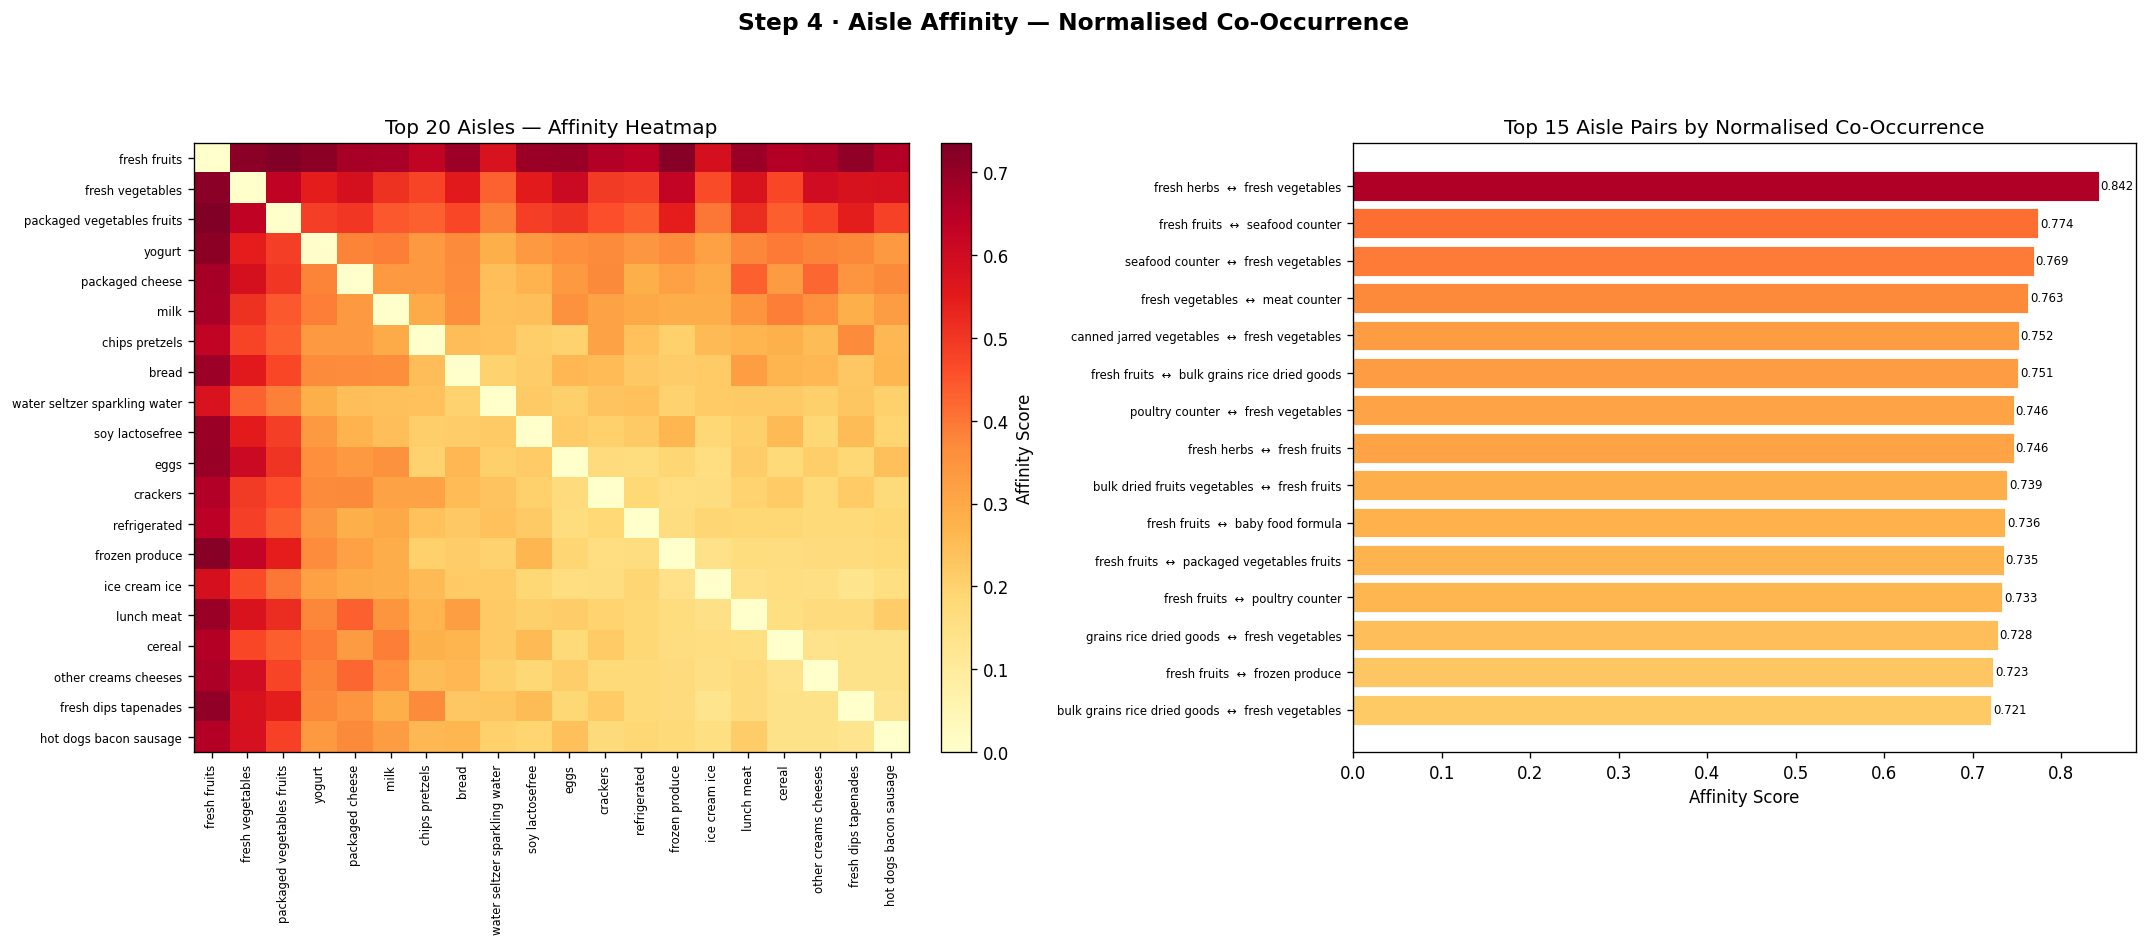

In [148]:
# ─── STEP 4 VISUALIZATION ─────────────────────────────────────────────
# Two charts: (1) Heatmap showing co-occurrence between top 20 aisles,
# (2) Bar chart of the top 15 strongest aisle pairs

# Select the 20 aisles with the highest total affinity across all partners
totals = affinity_df.sum(axis=1).sort_values(ascending=False)
top_items = totals.head(20).index
sub = affinity_df.loc[top_items, top_items]
heatmap_labels = [aisle_names.get(idx, str(idx)) for idx in sub.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Step 4 · Aisle Affinity — Normalised Co-Occurrence', fontsize=14, fontweight='bold')

# LEFT CHART: Heatmap — brighter/warmer colors mean stronger co-occurrence
# Clusters of warm colors reveal natural "shopping neighborhoods" in the store
im = axes[0].imshow(sub.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(heatmap_labels)))
axes[0].set_yticks(range(len(heatmap_labels)))
axes[0].set_xticklabels(heatmap_labels, rotation=90, fontsize=7)
axes[0].set_yticklabels(heatmap_labels, fontsize=7)
axes[0].set_title('Top 20 Aisles — Affinity Heatmap')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='Affinity Score')

# RIGHT CHART: The 15 strongest aisle pairings, ranked
# These pairs are the strongest candidates for co-placement or bundle promotions
pair_labels = [f"{r['aisle_a']}  ↔  {r['aisle_b']}" for _, r in top_pairs.iterrows()]
scores = top_pairs['affinity_score'].values
pair_labels.reverse(); scores = scores[::-1]
cmap_bar = plt.cm.YlOrRd
norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
bar_colors = [cmap_bar(0.3 + 0.6 * ns) for ns in norm_scores]
bars = axes[1].barh(range(len(pair_labels)), scores, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(pair_labels)))
axes[1].set_yticklabels(pair_labels, fontsize=7)
axes[1].set_xlabel('Affinity Score')
axes[1].set_title('Top 15 Aisle Pairs by Normalised Co-Occurrence')
for bar, val in zip(bars, scores):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=7)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Step 5: Cross-Sell Bundles (Item-Item Collaborative Filtering)

**Business Question:** Which products should we recommend together?

**Algorithm:** Item-Item Collaborative Filtering using **Jaccard similarity** on a User × Product binary matrix.

$$J(A, B) = \frac{|\text{users who bought both A and B}|}{|\text{users who bought A or B}|}$$

Jaccard (0–1) normalises by the union of buyer sets, so a niche product paired with a blockbuster is scored fairly.

> **Ref:** Jaccard, P. (1912). "The Distribution of the Flora in the Alpine Zone." *New Phytologist*, 11(2), 37-50.

Products purchased by similar sets of users are cross-sell candidates — the same approach behind Amazon's recommendation engine.

> **Ref:** Linden et al. (2003). "Amazon.com Recommendations: Item-to-Item Collaborative Filtering." *IEEE Internet Computing*, 7(1), 76-80.

In [149]:
# ─── STEP 5: CROSS-SELL — BUILDING THE SIMILARITY MATRIX ─────────────
# Goal: For every product, find the products most frequently bought by
# the same customers — the classic "customers who bought X also bought Y."
# Business Value: Powers product recommendations, bundle deals, and
# "also bought" features — proven to increase average order value by 15-25%.

# This uses "Item-Item Collaborative Filtering" with Jaccard Similarity,
# the same foundational approach Amazon used in their early recommendation engine.

MAX_PRODUCTS = 2000

# Connect each product purchase to the customer who bought it
merged_cf = op_pd[['order_id', 'product_id']].merge(
    orders_pd[['order_id', 'user_id']], on='order_id', how='inner'
)
# Count how many times each product was purchased
product_counts = merged_cf['product_id'].value_counts()
# top_products = product_counts.head(MAX_PRODUCTS).index.tolist()
top_products = product_counts.index.tolist()
merged_cf = merged_cf[merged_cf['product_id'].isin(top_products)]

# Build a "customer × product" matrix: each row is a customer, each column is a product
# A 1 means that customer has purchased that product at some point
product_ids_sorted = sorted(top_products)
pid_to_idx = {pid: i for i, pid in enumerate(product_ids_sorted)}
user_ids = merged_cf['user_id'].unique()
uid_to_idx = {uid: i for i, uid in enumerate(user_ids)}

rows = merged_cf['user_id'].map(uid_to_idx).values
cols = merged_cf['product_id'].map(pid_to_idx).values
data = np.ones(len(merged_cf), dtype=np.float32)
user_product_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(product_ids_sorted)))
# Convert to binary (1 = bought, 0 = never bought) — we don't care how many times
user_product_matrix = (user_product_matrix > 0).astype(np.float32)

# Calculate Jaccard Similarity between all pairs of products
# Jaccard = (customers who bought BOTH A and B) / (customers who bought A OR B)
# High Jaccard score means the two products appeal to the same customer base
mat_bool = (user_product_matrix > 0).astype(np.float32)
intersection = (mat_bool.T @ mat_bool).toarray()
col_sums = np.asarray(mat_bool.sum(axis=0)).flatten()
union = col_sums[:, None] + col_sums[None, :] - intersection
with np.errstate(divide='ignore', invalid='ignore'):
    sim_matrix = np.where(union > 0, intersection / union, 0.0).astype(np.float32)
# A product is always 100% similar to itself — remove that to focus on real associations
np.fill_diagonal(sim_matrix, 0)

display(sim_matrix)
print(f'Built Jaccard similarity matrix: {len(product_ids_sorted):,} products × {len(user_ids):,} users')


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(44371, 44371), dtype=float32)

Built Jaccard similarity matrix: 44,371 products × 30,931 users


In [150]:
# ─── STEP 5: CROSS-SELL RECOMMENDATIONS FOR OUR CASE STUDY PRODUCT ───
# For Cucumber Kirby, find the 10 products most often bought by the
# same customers — these are the strongest cross-sell opportunities.

if PRODUCT_ID in pid_to_idx:
    idx = pid_to_idx[PRODUCT_ID]
    # Get the similarity scores between Cucumber Kirby and every other product
    similarities = sim_matrix[idx]
    # Pick the top 10 most similar products
    top_indices = np.argsort(similarities)[::-1][:10]

    # Build a readable list of cross-sell candidates with their similarity scores
    assoc = []
    for i in top_indices:
        sim = similarities[i]
        if sim <= 0: continue
        pid = product_ids_sorted[i]
        name_row = products_pd[products_pd['product_id'] == pid]
        name = name_row.iloc[0]['product_name'] if not name_row.empty else None
        assoc.append((pid, float(sim), name))

    # Display the recommendations — "Customers who bought Cucumber Kirby also bought…"
    # These products should be featured together in bundles, suggested add-ons, and promotions
    print(f'Cross-sell candidates for "{PRODUCT_NAME}":\n')
    for pid, sim, name in assoc:
        label = name if name else f'product_id={pid}'
        print(f'  {label:40s} similarity={sim:.3f}')
else:
    assoc = []
    print(f'{PRODUCT_NAME} not in top {MAX_PRODUCTS} products.')


Cross-sell candidates for "Cucumber Kirby":

  Large Lemon                              similarity=0.229
  Organic Avocado                          similarity=0.218
  Banana                                   similarity=0.214
  Limes                                    similarity=0.214
  Organic Baby Spinach                     similarity=0.197
  Organic Strawberries                     similarity=0.174
  Organic Grape Tomatoes                   similarity=0.172
  Strawberries                             similarity=0.172
  Yellow Onions                            similarity=0.172
  Organic Zucchini                         similarity=0.167


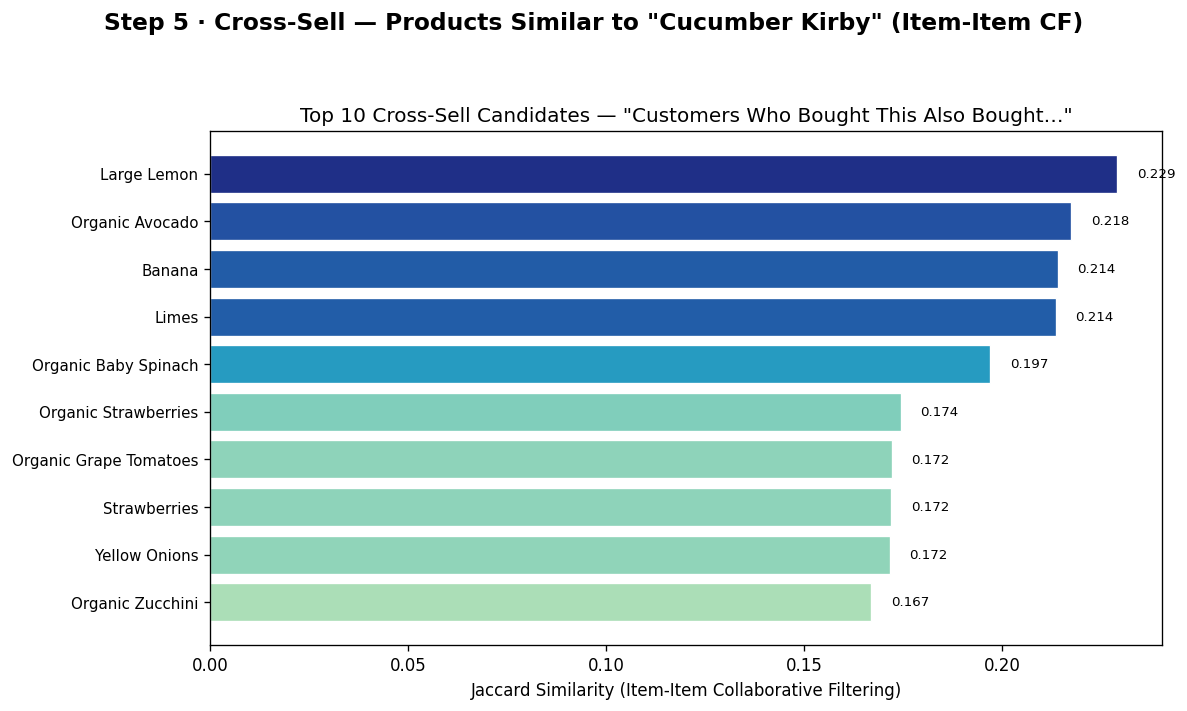

In [151]:
# ─── STEP 5 VISUALIZATION ─────────────────────────────────────────────
# Bar chart showing the top 10 cross-sell candidates for Cucumber Kirby
# Higher similarity means more customers buy both products together

if assoc:
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'Step 5 · Cross-Sell — Products Similar to "{PRODUCT_NAME}" (Item-Item CF)',
                 fontsize=14, fontweight='bold')

    names = [name if name else f'id={pid}' for pid, _, name in assoc]
    sims = [sim for _, sim, _ in assoc]
    names.reverse(); sims.reverse()

    # Color gradient: darker blue = stronger similarity = higher cross-sell potential
    cmap = plt.cm.YlGnBu
    norm_sims = [(s - min(sims)) / (max(sims) - min(sims) + 1e-9) for s in sims]
    colors = [cmap(0.3 + 0.6 * ns) for ns in norm_sims]
    bars = ax.barh(range(len(names)), sims, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Jaccard Similarity (Item-Item Collaborative Filtering)')
    ax.set_title('Top 10 Cross-Sell Candidates — "Customers Who Bought This Also Bought…"')
    # Annotate each bar with the exact similarity score
    for bar, val in zip(bars, sims):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


---
## Step 6: Shopping Mission Discovery

**Business Question:** Why do customers visit the store? What distinct shopping "missions" exist in the data?

Not every trip is the same. Some customers pop in for a quick fruit top-up; others do a full weekly pantry stock-up. Understanding these mission types lets retailers:
- **Optimise store layout** — place mission-related products closer together
- **Create targeted promotions** — "Complete your smoothie run" bundles
- **Personalise the app experience** — surface relevant categories based on detected trip intent

**Method:** We analyse the product mix of each order to discover natural groupings of shopping trips. Each mission is automatically labelled by its dominant product category.

In [173]:
# ─── STEP 6: TRIP MISSIONS — BUILDING THE ORDER MATRIX ────────────────
# Goal: Cluster shopping orders into distinct "missions" — like "weekly
# grocery stock-up" vs. "quick snack run" vs. "dinner party prep."
# Business Value: Lets marketing create targeted campaigns and bundles
# for each shopping occasion rather than one-size-fits-all promotions.

# Configuration: we'll discover 7 distinct shopping missions
N_MISSIONS = 7
MAX_MISSION_PRODUCTS = 1000
MAX_ORDERS = 2_000_000
# Orders with fewer than 3 products are too small to reveal a clear mission
MIN_PRODUCTS = 3

# Start with all products and their purchase frequencies
product_freq = op_pd['product_id'].value_counts()
# top_mission_pids = product_freq.head(MAX_MISSION_PRODUCTS).index
top_mission_pids = product_freq.index
filtered = op_pd[op_pd['product_id'].isin(top_mission_pids)].copy()

# Remove tiny orders (< 3 items) — they don't carry enough signal to identify a mission
order_counts_m = filtered.groupby('order_id')['product_id'].count()
valid_orders = order_counts_m[order_counts_m >= MIN_PRODUCTS].index
filtered = filtered[filtered['order_id'].isin(valid_orders)]

# If we have too many orders, take a random sample to keep computation feasible
unique_orders_m = filtered['order_id'].unique()
if len(unique_orders_m) > MAX_ORDERS:
    rng = np.random.RandomState(42)
    unique_orders_m = rng.choice(unique_orders_m, size=MAX_ORDERS, replace=False)
    filtered = filtered[filtered['order_id'].isin(unique_orders_m)]

# Build the order matrix: each row is one shopping trip, each column is a product
# A 1 means that product was in that order — this represents the "basket signature"
oid_to_idx = {oid: i for i, oid in enumerate(sorted(unique_orders_m))}
mpid_to_idx = {pid: j for j, pid in enumerate(sorted(top_mission_pids))}
product_columns = sorted(top_mission_pids)

r_idx = filtered['order_id'].map(oid_to_idx).values
c_idx = filtered['product_id'].map(mpid_to_idx).values
valid_mask = ~(np.isnan(r_idx) | np.isnan(c_idx))
r_idx = r_idx[valid_mask].astype(int)
c_idx = c_idx[valid_mask].astype(int)

print(r_idx, c_idx)

order_matrix = csr_matrix(
    (np.ones(len(r_idx), dtype=np.int8), (r_idx, c_idx)),
    shape=(len(oid_to_idx), len(mpid_to_idx)),
)

print(f'Order matrix: {order_matrix.shape[0]:,} orders × {order_matrix.shape[1]} products (sparse)')


[     0      0      0 ... 434097 434097 434097] [17533 18902  6650 ... 16623 24062 16985]
Order matrix: 434,098 orders × 44371 products (sparse)


In [175]:
# ─── STEP 6: CLUSTERING ORDERS INTO SHOPPING MISSIONS ─────────────────
# We use K-Means clustering to group similar shopping baskets together
# Each cluster represents a distinct "shopping mission" or trip type

# First, reduce the dimensionality of the order matrix using SVD
# This compresses thousands of product columns into 50 meaningful dimensions
# while preserving the key patterns — like creating a summary of each basket
n_components = min(50, order_matrix.shape[1] - 1, order_matrix.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
reduced = svd.fit_transform(order_matrix)
# Normalize so that each order's summary has equal weight regardless of basket size
reduced_norm = normalize(reduced)

# K-Means groups similar baskets together into 7 clusters (missions)
# It finds natural groupings — e.g., "orders heavy on fresh produce" vs. "orders heavy on snacks"
kmeans = KMeans(n_clusters=N_MISSIONS, random_state=42, n_init=10, max_iter=300)
kmeans.fit(reduced_norm)

# Each order now has a mission label (0 through 6)
labels = kmeans.labels_
# Calculate the "average basket" for each mission — which products define it
cluster_centers = np.zeros((N_MISSIONS, order_matrix.shape[1]))
for k in range(N_MISSIONS):
    mask = labels == k
    print(labels)
    if mask.sum() > 0:
        cluster_centers[k] = np.asarray(order_matrix[mask].mean(axis=0)).flatten()

# ─── NAME THE MISSIONS ───────────────────────────────────────────────
# Convert product-level clusters into business-friendly mission names
# by looking at which aisles and categories dominate each cluster

# Lookup tables for translating product IDs into business categories
pid_to_aisle = dict(zip(products_pd['product_id'], products_pd['aisle_id']))
aisle_id_to_name = dict(zip(aisles_pd['aisle_id'], aisles_pd['aisle']))
pid_to_name = dict(zip(products_pd['product_id'], products_pd['product_name']))

# Map detailed aisle names to broader business categories
# This simplifies 134 aisles into ~10 easy-to-understand shopping categories
AISLE_TO_CATEGORY = {
    'fresh fruits': 'Fresh Produce', 'fresh vegetables': 'Fresh Produce',
    'fresh herbs': 'Fresh Produce', 'packaged vegetables fruits': 'Fresh Produce',
    'packaged produce': 'Fresh Produce',
    'milk': 'Pantry Stock-Up', 'bread': 'Pantry Stock-Up',
    'eggs': 'Pantry Stock-Up', 'cereal': 'Pantry Stock-Up',
    'dry pasta': 'Pantry Stock-Up', 'grains rice dried goods': 'Pantry Stock-Up',
    'canned meals beans': 'Pantry Stock-Up', 'canned goods': 'Pantry Stock-Up',
    'condiments': 'Pantry Stock-Up', 'spices seasonings': 'Pantry Stock-Up',
    'oils vinegars': 'Pantry Stock-Up', 'baking ingredients': 'Pantry Stock-Up',
    'baking supplies decor': 'Pantry Stock-Up', 'pasta sauce': 'Pantry Stock-Up',
    'butter': 'Pantry Stock-Up',
    'water seltzer sparkling water': 'Snacking & Beverages', 'soft drinks': 'Snacking & Beverages',
    'energy sports drinks': 'Snacking & Beverages', 'chips pretzels': 'Snacking & Beverages',
    'crackers': 'Snacking & Beverages', 'popcorn jerky': 'Snacking & Beverages',
    'cookies cakes': 'Snacking & Beverages', 'trail mix snack mix': 'Snacking & Beverages',
    'juice nectars': 'Snacking & Beverages', 'ice cream ice': 'Snacking & Beverages',
    'fruit vegetable snacks': 'Snacking & Beverages',
    'yogurt': 'Breakfast & Dairy', 'breakfast bakery': 'Breakfast & Dairy',
    'breakfast bars pastries': 'Breakfast & Dairy', 'cream': 'Breakfast & Dairy',
    'granola': 'Breakfast & Dairy', 'energy granola bars': 'Breakfast & Dairy',
    'soy lactosefree': 'Breakfast & Dairy',
    'beers coolers': 'Entertaining & Drinks', 'red wines': 'Entertaining & Drinks',
    'white wines': 'Entertaining & Drinks', 'spirits': 'Entertaining & Drinks',
    'specialty wines champagnes': 'Entertaining & Drinks',
    'frozen appetizers sides': 'Entertaining & Drinks',
    'fresh dips tapenades': 'Entertaining & Drinks',
    'frozen meals': 'Quick Meal Prep', 'frozen pizza': 'Quick Meal Prep',
    'frozen breakfast': 'Quick Meal Prep', 'prepared meals': 'Quick Meal Prep',
    'instant foods': 'Quick Meal Prep', 'frozen meat seafood': 'Quick Meal Prep',
    'frozen vegan vegetarian': 'Quick Meal Prep',
    'packaged meat': 'Meat & Protein', 'packaged poultry': 'Meat & Protein',
    'meat counter': 'Meat & Protein', 'poultry counter': 'Meat & Protein',
    'seafood counter': 'Meat & Protein', 'hot dogs bacon sausage': 'Meat & Protein',
    'lunch meat': 'Meat & Protein', 'packaged seafood': 'Meat & Protein',
    'cleaning products': 'Household Essentials', 'paper goods': 'Household Essentials',
    'laundry': 'Household Essentials', 'trash bags liners': 'Household Essentials',
    'dish detergents': 'Household Essentials', 'food storage': 'Household Essentials',
    'air fresheners candles': 'Household Essentials',
    'diapers wipes': 'Baby & Family', 'baby food formula': 'Baby & Family',
    'baby accessories': 'Baby & Family', 'baby bath body care': 'Baby & Family',
    'hair care': 'Personal Care', 'body lotions soap': 'Personal Care',
    'skin care': 'Personal Care', 'oral hygiene': 'Personal Care',
    'deodorants': 'Personal Care', 'facial care': 'Personal Care',
    'soap': 'Personal Care', 'shave needs': 'Personal Care',
    'specialty cheeses': 'Deli & Specialty', 'packaged cheese': 'Deli & Specialty',
    'other creams cheeses': 'Deli & Specialty', 'prepared soups salads': 'Deli & Specialty',
    'coffee': 'Pantry Stock-Up', 'tea': 'Pantry Stock-Up',
}

def _name_mission(center, top_n=15):
    """Derive a business-friendly mission name from dominant aisles + organic flag."""
    top_idx = np.argsort(center)[::-1][:top_n]
    cat_scores = {}
    organic_weight, total_weight = 0.0, 0.0
    for idx in top_idx:
        pid = product_columns[idx]
        w = center[idx]
        total_weight += w
        pname = pid_to_name.get(pid, '')
        if 'organic' in pname.lower():
            organic_weight += w
        aid = pid_to_aisle.get(pid)
        if aid is not None:
            aname = aisle_id_to_name.get(aid, '')
            cat = AISLE_TO_CATEGORY.get(aname, 'General Shopping')
            cat_scores[cat] = cat_scores.get(cat, 0) + w
    ranked = sorted(cat_scores.items(), key=lambda x: -x[1])
    is_organic = organic_weight / (total_weight + 1e-9) > 0.5
    if ranked:
        base = ranked[0][0]
        if is_organic and base == 'Fresh Produce':
            return 'Organic & Health-Conscious'
        if is_organic:
            return f'Organic {base}'
        return base
    return 'General Shopping'

# Assign a descriptive business name to each mission cluster
mission_names = {}
used_names = {}
total_orders = len(labels)
for k in range(N_MISSIONS):
    mname = _name_mission(cluster_centers[k])
    used_names[mname] = used_names.get(mname, 0) + 1
    if used_names[mname] > 1:
        mname = f'{mname} #{used_names[mname]}'
    mission_names[k] = mname

# Display each mission with its size and signature products
print(f'{N_MISSIONS} Shopping Missions Discovered\n')
for k in range(N_MISSIONS):
    n_orders = (labels == k).sum()
    pct = n_orders / total_orders * 100
    mname = mission_names[k]
    top_idx = np.argsort(cluster_centers[k])[::-1][:5]
    top_names = []
    for idx in top_idx:
        pid = product_columns[idx]
        row = products_pd[products_pd['product_id'] == pid]
        top_names.append(row.iloc[0]['product_name'] if not row.empty else str(pid))
    size_label = 'Large' if pct > 20 else ('Medium' if pct > 10 else 'Niche')
    print(f'  {mname}  [{size_label} — {n_orders:,} orders, {pct:.1f}%]')
    print(f'    Signature products: {" · ".join(top_names)}')
    print()


[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
[2 2 3 ... 2 3 1]
7 Shopping Missions Discovered

  Organic & Health-Conscious  [Niche — 32,152 orders, 7.4%]
    Signature products: Organic Baby Spinach · Organic Avocado · Large Lemon · Limes · Banana

  Organic & Health-Conscious #2  [Niche — 34,829 orders, 8.0%]
    Signature products: Organic Strawberries · Organic Hass Avocado · Organic Raspberries · Organic Baby Spinach · Organic Blueberries

  Organic & Health-Conscious #3  [Large — 170,715 orders, 39.3%]
    Signature products: Large Lemon · Limes · Strawberries · Organic Whole Milk · Organic Raspberries

  Fresh Produce  [Niche — 23,122 orders, 5.3%]
    Signature products: Raspberries · Hass Avocados · Soda · Clementines · Blueberries

  Pantry Stock-Up  [Medium — 57,382 orders, 13.2%]
    Signature products: 100% Whole Wheat Bread · 2% Reduced Fat Milk · Whole Milk · Fridge Pack Cola · Fat Free Milk

  Organic & Heal

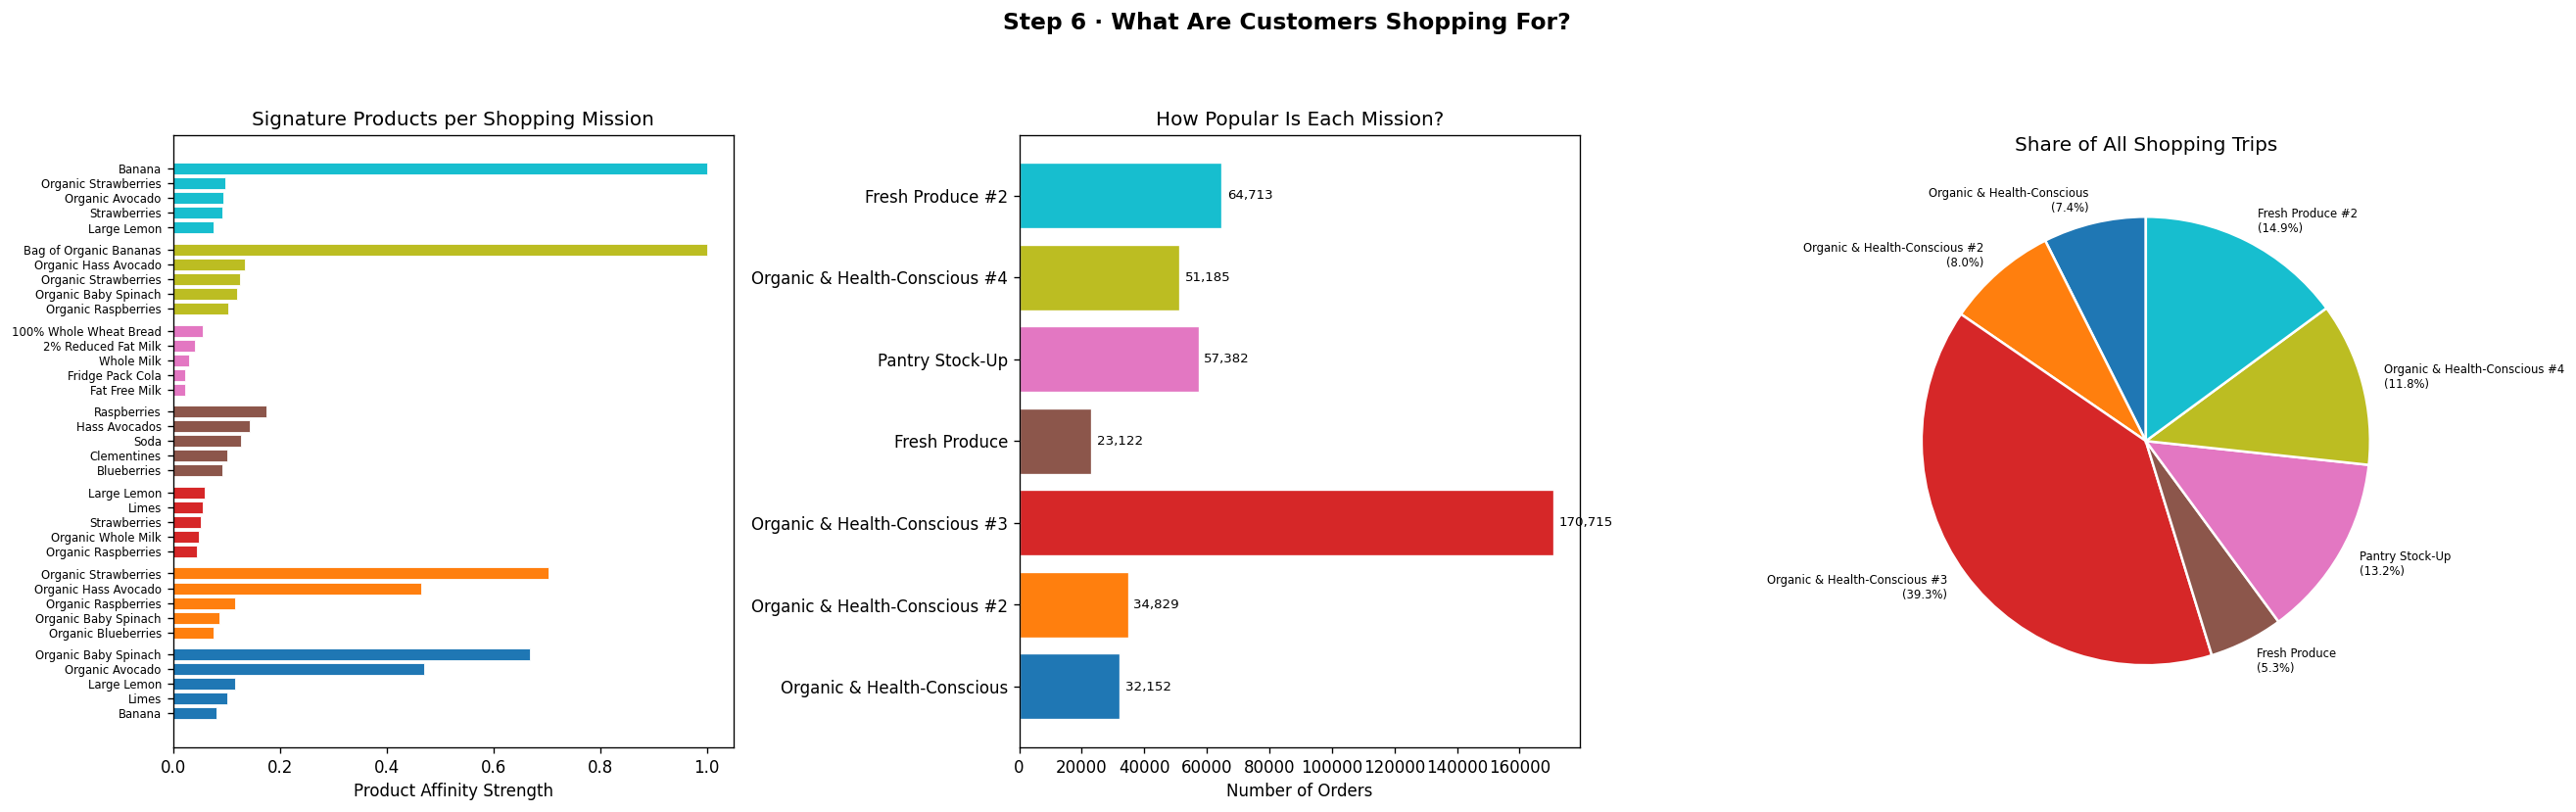

In [172]:
# ─── STEP 6 VISUALIZATION ─────────────────────────────────────────────
# Three charts: (1) Signature products per mission, (2) Mission popularity,
# (3) Share-of-trips pie chart — these help marketing allocate campaign budgets

# Prepare data for the charts — gather the top 5 signature products per mission
mission_data = []
mlabels_biz = []
for mid in range(N_MISSIONS):
    mname = mission_names[mid]
    mlabels_biz.append(mname)
    top_idx = np.argsort(cluster_centers[mid])[::-1][:5]
    for idx in top_idx:
        pid = product_columns[idx]
        weight = cluster_centers[mid][idx]
        if weight <= 0: continue
        row = products_pd[products_pd['product_id'] == pid]
        name = row.iloc[0]['product_name'] if not row.empty else str(pid)
        mission_data.append({'mission': mname, 'product': name, 'weight': weight})
mdf = pd.DataFrame(mission_data)

# Count how many orders fall into each mission
order_counts_per_mission = pd.Series(
    {mission_names[k]: (labels == k).sum() for k in range(N_MISSIONS)}
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Step 6 · What Are Customers Shopping For?', fontsize=14, fontweight='bold')

# LEFT CHART: Products that define each mission — the "DNA" of each shopping trip type
cmap_m = plt.cm.tab10
y_pos, y_lab, y_col, y_wid = [], [], [], []
gap = 0
for mid, mname in enumerate(mlabels_biz):
    sub = mdf[mdf['mission'] == mname].sort_values('weight', ascending=True)
    for _, row in sub.iterrows():
        y_pos.append(gap); y_lab.append(row['product'])
        y_col.append(cmap_m(mid / max(N_MISSIONS - 1, 1))); y_wid.append(row['weight'])
        gap += 1
    gap += 0.5

axes[0].barh(y_pos, y_wid, color=y_col, edgecolor='white', linewidth=0.5, height=0.8)
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(y_lab, fontsize=7)
axes[0].set_xlabel('Product Affinity Strength')
axes[0].set_title('Signature Products per Shopping Mission')

# MIDDLE CHART: How popular is each mission? This drives budget allocation
oc_sorted = order_counts_per_mission.reindex(mlabels_biz)
m_colors = [cmap_m(i / max(N_MISSIONS - 1, 1)) for i in range(N_MISSIONS)]
bars = axes[1].barh(mlabels_biz, oc_sorted.values, color=m_colors, edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('How Popular Is Each Mission?')
for bar, val in zip(bars, oc_sorted.values):
    axes[1].text(bar.get_width() + oc_sorted.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', ha='left', va='center', fontsize=8)

# RIGHT CHART: Pie chart — what percentage of all shopping trips does each mission represent?
pct_vals = oc_sorted.values / oc_sorted.values.sum() * 100
axes[2].pie(pct_vals, labels=[f'{n}\n({p:.1f}%)' for n, p in zip(mlabels_biz, pct_vals)],
            colors=m_colors, startangle=90, textprops={'fontsize': 7},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Share of All Shopping Trips')

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---
## Step 7: Reorder Propensity (Logistic Regression)

**Business Question:** Among products a user has purchased before, which ones will they include in their next order?

**Approach — Prior → Train split (Kaggle-style):**
- **Feature history** — `order_products__prior.csv` (`op_pd`), already loaded. Contains every order-product row from a user's full prior purchase history.
- **Prediction target** — `order_products__train.csv` (`op_train_pd`). Each user has exactly one "train" order. Products present = **reordered (1)**, products previously bought but absent = **not reordered (0)**.

This mirrors the original Instacart Kaggle competition structure and avoids synthetic hold-out from the prior file.

**Algorithm:** Logistic Regression with features derived from prior purchase history:
- `purchase_count` — how many times the user bought this product (prior orders)
- `orders_since_last` — how many orders ago they last bought it
- `product_cycle` — average repurchase interval (days)
- `recency_decay` — exponential decay of last purchase
- `purchase_freq` — fraction of user's orders containing this product

In [162]:
# ─── STEP 7: REORDER PROPENSITY — FEATURE ENGINEERING ─────────────────
# Goal: Build a predictive model that forecasts which products each
# customer will reorder in their next shopping trip.
# Business Value: Powers personalized "reorder" suggestions timed to
# each customer's buying cycle — increases conversion and basket size.

# --- Prior → Train split (Kaggle-style) ---
# History: all prior orders (op_pd) — what customers have bought in the past
# Target:  train orders (op_train_pd) — what customers actually bought next (our prediction target)

# Combine order details with product purchases to create a complete purchase history
history = op_pd[['order_id', 'product_id']].merge(
    orders_pd[['order_id', 'user_id', 'order_number', 'days_since_prior_order']],
    on='order_id', how='inner'
)

# Identify the customers who have a "train" order (i.e., a known next order to predict)
train_orders = orders_pd[orders_pd['eval_set'] == 'train'][['order_id', 'user_id']]
train_users = set(train_orders['user_id'].unique())
# Only keep history for customers we can validate predictions against
history = history[history['user_id'].isin(train_users)]

# Find each customer's most recent order number — this helps measure "recency"
user_max = history.groupby('user_id')['order_number'].max().reset_index(name='max_prior_order')

# ─── BUILD FEATURES FOR EACH CUSTOMER-PRODUCT PAIR ───────────────────
# For every (customer, product) combination, calculate behavioral signals
# that indicate how likely the customer is to reorder that product

up = (
    history.sort_values(['user_id', 'product_id', 'order_number'])
    .groupby(['user_id', 'product_id'])
    .agg(
        # How many times has this customer bought this specific product?
        purchase_count=('order_id', 'count'),
        # When did the customer last buy this product?
        last_order_num=('order_number', 'max'),
        # On average, how many days between this customer's orders?
        avg_days=('days_since_prior_order', 'mean'),
    )
    .reset_index()
)
up = up.merge(user_max, on='user_id')
# How many orders ago was the last purchase? Lower = more recent = more likely to reorder
up['orders_since_last'] = up['max_prior_order'] - up['last_order_num']

# Calculate the typical "repurchase cycle" for each product across all customers
# e.g., milk might be bought every 7 days, while olive oil every 30 days
prod_cycles = (
    history.sort_values(['user_id', 'product_id', 'order_number'])
    .pipe(lambda df: df[df.groupby(['user_id', 'product_id']).cumcount() >= 1])
    .groupby('product_id')['days_since_prior_order']
    .mean()
    .reset_index(name='product_cycle')
)
up = up.merge(prod_cycles, on='product_id', how='left')
# Default to 30-day cycle for products with no repeat purchase data
up['product_cycle'] = up['product_cycle'].fillna(30)

# Customer-level features: how experienced/diverse is this shopper?
user_f = history.groupby('user_id').agg(
    # How many total orders has this customer placed?
    user_total_orders=('order_number', 'nunique'),
    # How many different products has this customer tried?
    user_distinct_products=('product_id', 'nunique')
).reset_index()
up = up.merge(user_f, on='user_id', how='left')

# Product-level features: how popular is this product overall?
prod_f = history.groupby('product_id').agg(
    # Total number of times this product has been ordered (by anyone)
    product_popularity=('order_id', 'count'),
    # How many different customers have bought this product?
    product_buyers=('user_id', 'nunique')
).reset_index()
up = up.merge(prod_f, on='product_id', how='left')

# Ground truth: products in op_train_pd → reordered=1
# This is what the customer ACTUALLY bought next — our prediction target
target_label = op_train_pd[['order_id', 'product_id']].merge(
    train_orders, on='order_id', how='inner'
)[['user_id', 'product_id']].drop_duplicates()
target_label['reordered'] = 1

# Merge the target: 1 = customer DID reorder this product, 0 = they did NOT
up = up.merge(target_label, on=['user_id', 'product_id'], how='left')
up['reordered'] = up['reordered'].fillna(0).astype(int)

# ─── ENGINEERED FEATURES ─────────────────────────────────────────────
# Create additional "smart" features that capture business intuition

# Recency decay: the more orders since last purchase, the less likely to reorder
# Products bought recently have a score near 1.0; older purchases decay toward 0
up['recency_decay'] = np.exp(-up['orders_since_last'] / (up['purchase_count'] + 1))
# Purchase frequency: what fraction of the customer's trips included this product?
# A product bought in 80% of trips is practically a staple for that customer
up['purchase_freq'] = up['purchase_count'] / up['user_total_orders']
# Binary flag: was the product in one of the last 2 orders? (strong reorder signal)
up['is_recent'] = (up['orders_since_last'] <= 2).astype(int)
# Binary flag: has the product NOT been bought in 5+ orders? (may have abandoned it)
up['is_stale'] = (up['orders_since_last'] >= 5).astype(int)

# Final list of features the model will use to make predictions
feature_columns = [
    'purchase_count', 'orders_since_last', 'product_cycle', 'avg_days',
    'user_total_orders', 'user_distinct_products',
    'product_popularity', 'product_buyers',
    'recency_decay', 'purchase_freq', 'is_recent', 'is_stale',
]
features_df = up[feature_columns + ['user_id', 'product_id', 'reordered']].fillna(0)

print(f'Train users:    {len(train_users):>10,}')
print(f'Feature matrix: {len(features_df):>10,} samples × {len(feature_columns)} features')
print(f'Reorder rate:   {features_df["reordered"].mean():.1%} (natural class balance)')


Train users:        19,742
Feature matrix:  1,272,484 samples × 12 features
Reorder rate:   9.8% (natural class balance)


In [163]:
# ─── STEP 7: TRAINING THE REORDER PREDICTION MODEL ────────────────────
# Train a Logistic Regression model that learns which customer-product
# behavior patterns predict a reorder. Then measure how accurate it is.

# Separate the features (inputs) from the target (what we're predicting)
X = features_df[feature_columns]
y = features_df['reordered']

# Split data: 80% for training, 20% for testing
# The model learns from training data and is evaluated on unseen test data
# "stratify" ensures the train/test split preserves the reorder ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features so they're all on the same scale
# Without this, a feature with values 0-1000 would unfairly dominate one with values 0-1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression model
# "balanced" class weights ensure the model doesn't just predict "won't reorder" for everything
# (since most customer-product pairs won't be reordered, the model could cheat by always saying "no")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set and evaluate accuracy
# The model outputs a probability (0 to 1) for each customer-product pair
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
# If probability ≥ 50%, we predict "will reorder"; otherwise "won't reorder"
y_pred = (y_pred_proba >= 0.5).astype(int)
# AUC-ROC measures how well the model distinguishes reorders from non-reorders
# 1.0 = perfect predictions, 0.5 = random guessing
auc_score = roc_auc_score(y_test, y_pred_proba)

# Feature importance: which behaviors matter most for predicting reorders?
# This tells us the KEY DRIVERS of customer repurchase decisions
fi = pd.DataFrame({'feature': feature_columns, 'importance': np.abs(lr_model.coef_[0])})
fi = fi.sort_values('importance', ascending=False)

print(f'AUC-ROC: {auc_score:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')
print('Top Most Important Features:')
display(fi)


AUC-ROC: 0.8157

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84    229565
           1       0.24      0.74      0.36     24932

    accuracy                           0.74    254497
   macro avg       0.60      0.74      0.60    254497
weighted avg       0.89      0.74      0.79    254497

Top Most Important Features:


,feature,importance
8,recency_decay,0.584406
1,orders_since_last,0.529974
9,purchase_freq,0.387208
7,product_buyers,0.176222
0,purchase_count,0.157198
10,is_recent,0.060204
2,product_cycle,0.058714
4,user_total_orders,0.047679
11,is_stale,0.035143
5,user_distinct_products,0.031137


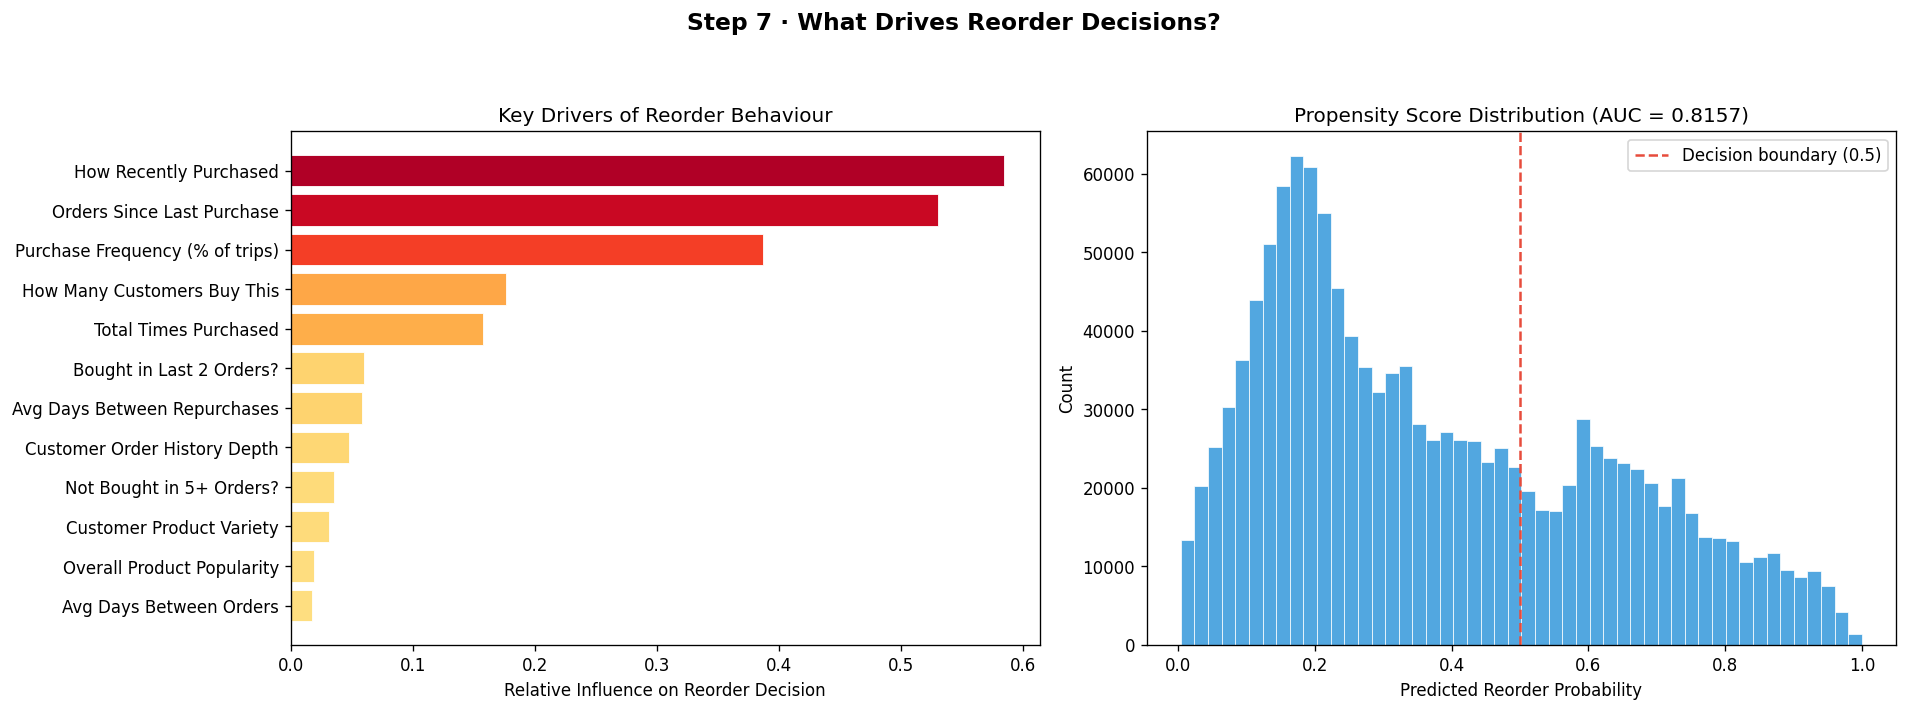

In [164]:
# ─── STEP 7 VISUALIZATION: WHAT DRIVES REORDER DECISIONS ──────────────
# Two charts: (1) Which factors matter most for reorders (business language),
# (2) Distribution of reorder probability scores across all customer-product pairs

# Translate technical feature names into business-friendly labels
BUSINESS_LABELS = {
    'recency_decay':          'How Recently Purchased',
    'orders_since_last':      'Orders Since Last Purchase',
    'purchase_freq':          'Purchase Frequency (% of trips)',
    'purchase_count':         'Total Times Purchased',
    'product_cycle':          'Avg Days Between Repurchases',
    'avg_days':               'Avg Days Between Orders',
    'user_total_orders':      'Customer Order History Depth',
    'user_distinct_products': 'Customer Product Variety',
    'product_popularity':     'Overall Product Popularity',
    'product_buyers':         'How Many Customers Buy This',
    'is_recent':              'Bought in Last 2 Orders?',
    'is_stale':               'Not Bought in 5+ Orders?',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Step 7 · What Drives Reorder Decisions?', fontsize=14, fontweight='bold')

# LEFT CHART: Feature importance — which behavioral signals predict reorders best?
# The longest bars are the factors marketing and product teams should focus on
fi_sorted = fi.sort_values('importance')
fi_sorted['label'] = fi_sorted['feature'].map(BUSINESS_LABELS).fillna(fi_sorted['feature'])
cmap_fi = plt.cm.YlOrRd
norm_fi = fi_sorted['importance'] / fi_sorted['importance'].max()
fi_colors = [cmap_fi(0.2 + 0.7 * v) for v in norm_fi.values]
axes[0].barh(fi_sorted['label'], fi_sorted['importance'], color=fi_colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Relative Influence on Reorder Decision')
axes[0].set_title('Key Drivers of Reorder Behaviour')

# RIGHT CHART: Histogram of predicted reorder probabilities
# Most scores cluster near 0 (unlikely to reorder) — the red line at 0.5 is the decision boundary
scores_all = lr_model.predict_proba(scaler.transform(X))[:, 1]
axes[1].hist(scores_all, bins=50, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Predicted Reorder Probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Propensity Score Distribution (AUC = {auc_score:.4f})')
axes[1].axvline(0.5, color='#e74c3c', ls='--', lw=1.5, label='Decision boundary (0.5)')
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


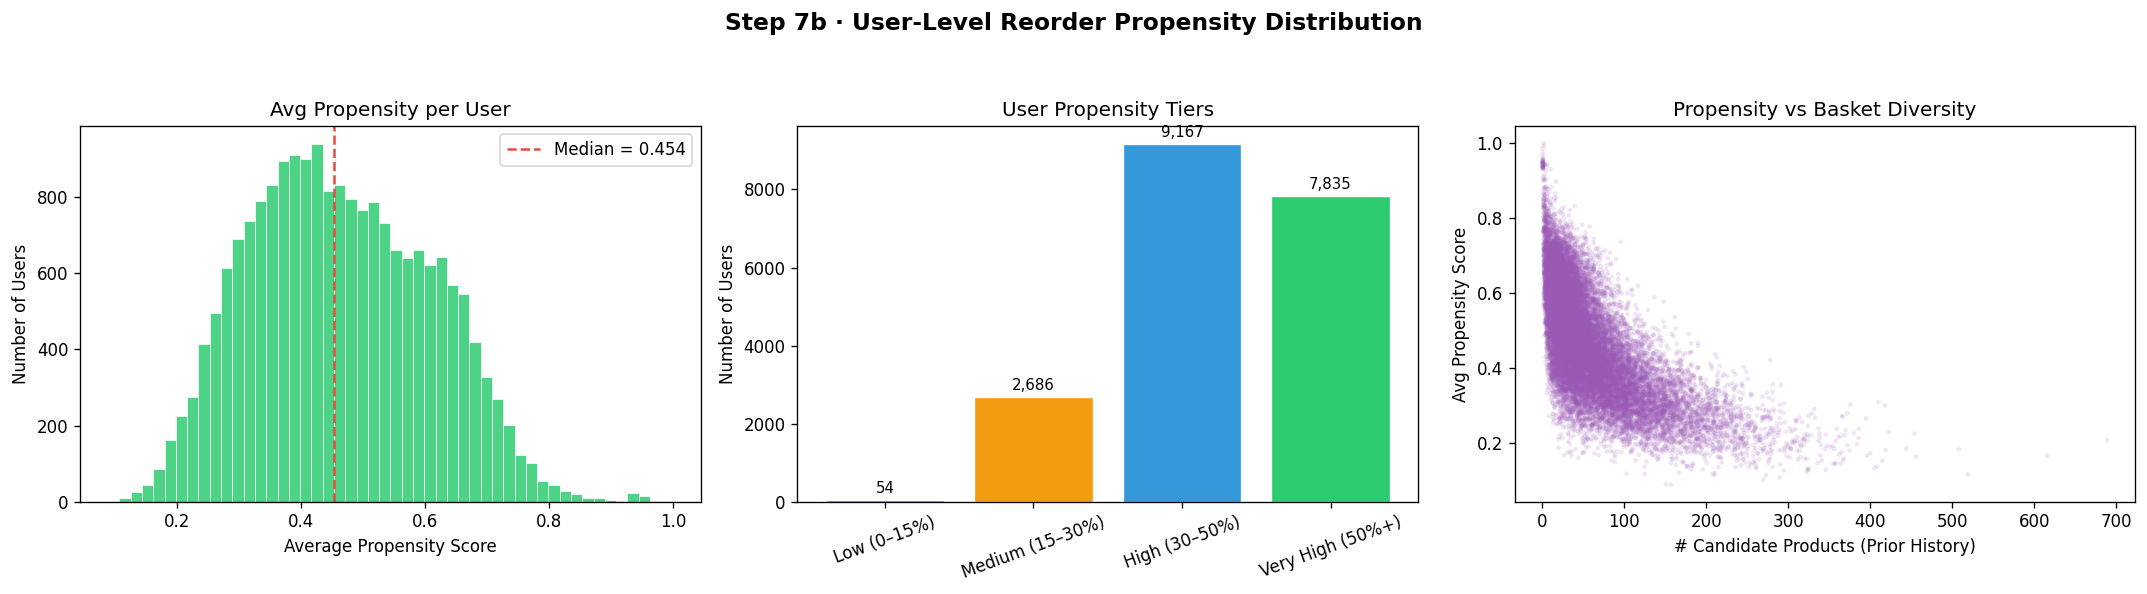


User-Level Summary:
  Total users:           19,742
  Median propensity:      0.454
  Mean propensity:        0.464

Tier Breakdown:
  Low (0–15%)                54 users (0.3%)
  Medium (15–30%)         2,686 users (13.6%)
  High (30–50%)           9,167 users (46.4%)
  Very High (50%+)        7,835 users (39.7%)


In [165]:
# ─── STEP 7b: USER-LEVEL REORDER PROPENSITY ──────────────────────────
# Aggregate product-level predictions up to the customer level
# This shows which customers are most likely to place a repeat order overall

# Calculate each customer's average, max, and candidate count for reorder scores
user_propensity = features_df[['user_id']].copy()
user_propensity['score'] = lr_model.predict_proba(scaler.transform(X))[:, 1]

user_agg = user_propensity.groupby('user_id')['score'].agg(
    avg_propensity='mean', max_propensity='max', n_candidates='count'
).reset_index()

# Tier customers by their average propensity to reorder
# This helps CRM teams prioritize outreach — "Very High" customers are loyal but may just
# need a reminder, while "Low" customers may need incentives to return
user_agg['tier'] = pd.cut(
    user_agg['avg_propensity'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low (0–15%)', 'Medium (15–30%)', 'High (30–50%)', 'Very High (50%+)']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 7b · User-Level Reorder Propensity Distribution', fontsize=14, fontweight='bold')

# LEFT CHART: Distribution of average propensity scores across all customers
axes[0].hist(user_agg['avg_propensity'], bins=50, color='#2ecc71', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_xlabel('Average Propensity Score')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Avg Propensity per User')
axes[0].axvline(user_agg['avg_propensity'].median(), color='#e74c3c', ls='--', lw=1.5,
                label=f'Median = {user_agg["avg_propensity"].median():.3f}')
axes[0].legend()

# MIDDLE CHART: How many customers fall into each propensity tier?
# This is the targeting breakdown for email campaigns and push notifications
tier_counts = user_agg['tier'].value_counts().reindex(
    ['Low (0–15%)', 'Medium (15–30%)', 'High (30–50%)', 'Very High (50%+)']
)
tier_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[1].bar(tier_counts.index, tier_counts.values, color=tier_colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('Number of Users')
axes[1].set_title('User Propensity Tiers')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + tier_counts.max() * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# RIGHT CHART: Scatter plot — do customers who buy more diverse products have lower reorder rates?
# Each dot is a customer; this reveals the relationship between variety-seeking and loyalty
axes[2].scatter(user_agg['n_candidates'], user_agg['avg_propensity'],
                alpha=0.15, s=8, color='#9b59b6', edgecolors='none')
axes[2].set_xlabel('# Candidate Products (Prior History)')
axes[2].set_ylabel('Avg Propensity Score')
axes[2].set_title('Propensity vs Basket Diversity')

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Print a summary table with counts and percentages for each tier
print(f'\nUser-Level Summary:')
print(f'  Total users:       {len(user_agg):>10,}')
print(f'  Median propensity: {user_agg["avg_propensity"].median():>10.3f}')
print(f'  Mean propensity:   {user_agg["avg_propensity"].mean():>10.3f}')
print(f'\nTier Breakdown:')
for tier, count in tier_counts.items():
    pct = count / len(user_agg) * 100
    print(f'  {tier:<20s} {count:>8,} users ({pct:.1f}%)')


---
## Business Summary

MBA-style strategic summary combining all pipeline insights.

In [166]:
# ─── EXECUTIVE SUMMARY ────────────────────────────────────────────────
# This cell consolidates all findings from the 7-step analysis into
# a single business-ready summary with actionable strategy recommendations

print('=' * 72)
print('BUSINESS SUMMARY — Instacart (Online) MBA Insights')
print('=' * 72)

# Case study product overview
print(f'\nProduct: {PRODUCT_NAME} (product_id={PRODUCT_ID})')

# Key business metrics for our case study product
print('\n📊 BUSINESS METRICS')
if purchase_count is not None:
    print(f'  Product velocity: {purchase_count:,} purchases ({velocity_tier})')
if avg_cart_position is not None:
    print(f'  Add-to-cart priority: avg position {avg_cart_position:.2f} ({priority_type})')
    if priority_type == 'Destination':
        print('  → Strategy: Anchor product — drives app visits & basket building')

# Aisle affinity findings — which aisles should be co-promoted?
print(f'\n🏬 AISLE AFFINITY (Normalised Co-Occurrence)')
print(f'  Product aisle: {product_aisle_label}')
print(f'  Top co-browsed aisles:')
for aid, score in aisle_partners.head(5).items():
    print(f'    - {aisle_names.get(aid, aid)} (affinity={score:.3f})')
print('  → Strategy: Feature these aisles in "You Might Also Browse" navigation')

# Cross-sell recommendations — "also bought" items
print('\n🛒 CROSS-SELL OPPORTUNITIES (Item-Item Collaborative Filtering)')
if assoc:
    print('  "Customers who bought this also bought…"')
    for pid, sim, name in assoc[:5]:
        label = name if name else f'product_id={pid}'
        print(f'    - {label} (similarity={sim:.3f})')
    print('  → Revenue Impact: Cross-selling top items can increase AOV by 15-25%')

# Shopping mission breakdown — what are the main reasons customers shop?
print('\n🎯 SHOPPING MISSIONS')
for k in range(N_MISSIONS):
    n_k = (labels == k).sum()
    pct = n_k / len(labels) * 100
    mname = mission_names.get(k, f'Mission {k+1}')
    top_idx = np.argsort(cluster_centers[k])[::-1][:3]
    top_names = []
    for idx in top_idx:
        pid = product_columns[idx]
        row = products_pd[products_pd['product_id'] == pid]
        top_names.append(row.iloc[0]['product_name'] if not row.empty else str(pid))
    print(f'  {mname} ({n_k:,} orders, {pct:.1f}%): {" · ".join(top_names)}')
print('  → Strategy: Bundle mission items for targeted promotions')

# Reorder propensity model — predictive power and key insights
print(f'\n📈 REORDER PROPENSITY')
print(f'  Model AUC-ROC: {auc_score:.4f}')
print(f'  Top driver: {fi.iloc[0]["feature"]} (importance={fi.iloc[0]["importance"]:.4f})')
print('  → Strategy: Time recommendations to product purchase cycles')

print('\n' + '=' * 72)


BUSINESS SUMMARY — Instacart (Online) MBA Insights

Product: Cucumber Kirby (product_id=49683)

📊 BUSINESS METRICS
  Product velocity: 15,097 purchases (High)
  Add-to-cart priority: avg position 7.56 (Considered)

🏬 AISLE AFFINITY (Normalised Co-Occurrence)
  Product aisle: fresh vegetables
  Top co-browsed aisles:
    - fresh herbs (affinity=0.842)
    - seafood counter (affinity=0.769)
    - meat counter (affinity=0.763)
    - canned jarred vegetables (affinity=0.752)
    - poultry counter (affinity=0.746)
  → Strategy: Feature these aisles in "You Might Also Browse" navigation

🛒 CROSS-SELL OPPORTUNITIES (Item-Item Collaborative Filtering)
  "Customers who bought this also bought…"
    - Large Lemon (similarity=0.229)
    - Organic Avocado (similarity=0.218)
    - Banana (similarity=0.214)
    - Limes (similarity=0.214)
    - Organic Baby Spinach (similarity=0.197)
  → Revenue Impact: Cross-selling top items can increase AOV by 15-25%

🎯 TRIP MISSIONS
  Mission 1 (32,152 orders): O